<a href="https://colab.research.google.com/github/leonovad/neuron-models/blob/main/hodgkin_huxley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hodgkin–Huxley model: the action potential from ion channels

Part 2 of the neuron-models series (Part 1: `lif_neuron.ipynb`).

In the LIF model the spike was a bookkeeping event: reach threshold, record, reset.
Here the spike is not written into the code at all — it *emerges* from three ionic
currents whose conductances depend on the membrane potential, which in turn depends
on the currents.

$$C\frac{dV}{dt} = I_{ext} - \bar g_{Na}\,m^3 h\,(V - E_{Na}) - \bar g_K\,n^4\,(V - E_K) - g_L\,(V - E_L)$$

Each gating variable $x \in \{m, h, n\}$ is the probability that one gate is open and obeys

$$\frac{dx}{dt} = \alpha_x(V)\,(1 - x) - \beta_x(V)\,x$$

$m$ — fast Na⁺ activation, $h$ — slow Na⁺ inactivation, $n$ — slow K⁺ activation.
The exponents (3 and 4) are the number of independent gates per channel. Rate functions
$\alpha$, $\beta$ are the original Hodgkin & Huxley (1952) fits to squid axon data, shifted so
that rest ≈ −65 mV.

Forward Euler with $dt = 0.01$ ms: the fast variable $m$ has a time constant of ~0.1 ms,
so the step must be well below that or the integration diverges.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hh(I_amp, T=50.0, dt=0.01, t_on=10.0, t_off=40.0):
    # Hodgkin–Huxley single compartment. Returns t, V, gNa(t), gK(t).
    C = 1.0                              # uF/cm^2
    gNa, gK, gL = 120.0, 36.0, 0.3       # max conductances, mS/cm^2
    ENa, EK, EL = 50.0, -77.0, -54.4     # reversal potentials, mV

    # rate functions alpha/beta (1/ms), original HH shifted to rest ≈ -65 mV
    am = lambda V: 0.1*(V+40)/(1-np.exp(-(V+40)/10))
    bm = lambda V: 4.0*np.exp(-(V+65)/18)
    ah = lambda V: 0.07*np.exp(-(V+65)/20)
    bh = lambda V: 1/(1+np.exp(-(V+35)/10))
    an = lambda V: 0.01*(V+55)/(1-np.exp(-(V+55)/10))
    bn = lambda V: 0.125*np.exp(-(V+65)/80)

    t = np.arange(0, T, dt)
    I = np.zeros_like(t); I[(t > t_on) & (t < t_off)] = I_amp   # uA/cm^2

    V = np.zeros_like(t); V[0] = -65.0
    # gates start at their steady state for V[0]
    m = am(V[0])/(am(V[0])+bm(V[0]))
    h = ah(V[0])/(ah(V[0])+bh(V[0]))
    n = an(V[0])/(an(V[0])+bn(V[0]))
    gNa_t, gK_t = np.zeros_like(t), np.zeros_like(t)

    for i in range(1, len(t)):
        v = V[i-1]
        INa = gNa * m**3 * h * (v - ENa)
        IK  = gK  * n**4     * (v - EK)
        IL  = gL             * (v - EL)
        V[i] = v + dt * (I[i] - INa - IK - IL) / C
        m += dt * (am(v)*(1-m) - bm(v)*m)
        h += dt * (ah(v)*(1-h) - bh(v)*h)
        n += dt * (an(v)*(1-n) - bn(v)*n)
        gNa_t[i], gK_t[i] = gNa*m**3*h, gK*n**4
    return t, V, gNa_t, gK_t

def count_spikes(V):
    # upward zero crossings
    return int(np.sum((V[1:] > 0) & (V[:-1] <= 0)))

## 1. Action potential

A 30 ms current step of 10 µA/cm². Unlike LIF, the potential overshoots zero and
undershoots the resting level after each spike, both without any threshold or reset in the code.

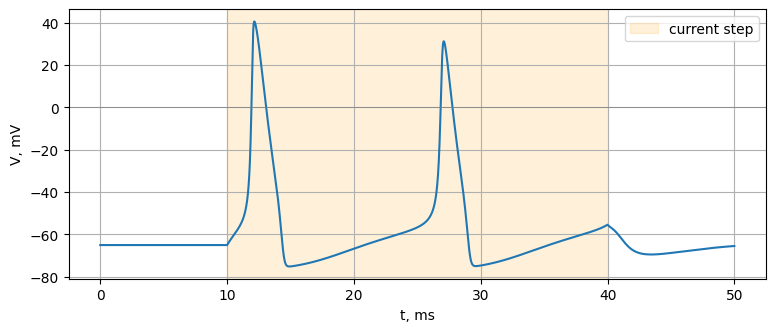

spikes: 2
peak (overshoot): 40.5 mV
after-hyperpolarisation: -75.1 mV


In [ ]:
t, V, gNa_t, gK_t = hh(10.0)

plt.figure(figsize=(9, 3.5))
plt.plot(t, V)
plt.axvspan(10, 40, color='orange', alpha=0.15, label='current step')
plt.axhline(0, c='gray', lw=0.5)
plt.xlabel('t, ms'); plt.ylabel('V, mV'); plt.legend(); plt.grid(True)
plt.show()

print(f"spikes: {count_spikes(V)}")
print(f"peak (overshoot): {V.max():.1f} mV")
print(f"after-hyperpolarisation: {V.min():.1f} mV")

## 2. Ionic conductances during the spike

Zoom on the first spike. $g_{Na}$ peaks first and collapses within ~1 ms while $V$ is still
depolarised — that is Na⁺ inactivation ($h$ closing), not repolarisation. $g_K$ peaks ~1.5 ms
later and decays slowly, keeping the membrane below rest after the spike (after-hyperpolarisation).
This ordering — fast Na⁺ in, delayed K⁺ out — is what makes the spike a one-way event.

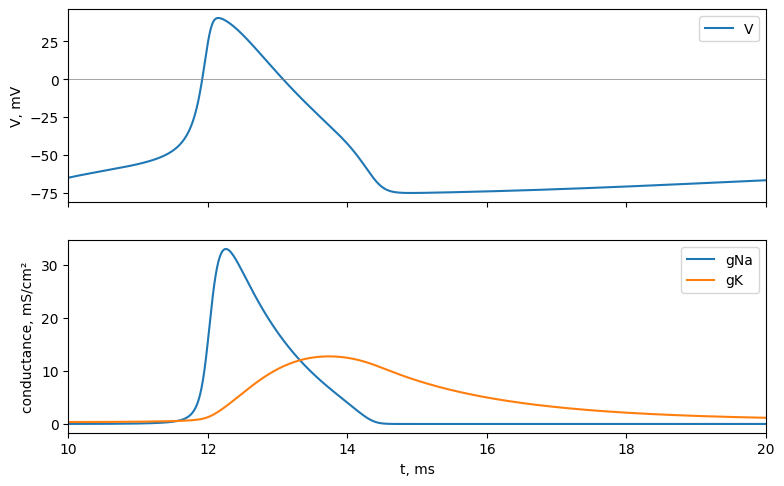

gNa peak at 12.26 ms, gK peak at 13.73 ms  (delay 1.47 ms)


In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
ax[0].plot(t, V, label='V'); ax[0].axhline(0, c='gray', lw=0.5)
ax[0].set_ylabel('V, mV'); ax[0].legend()
ax[1].plot(t, gNa_t, label='gNa'); ax[1].plot(t, gK_t, label='gK')
ax[1].set_ylabel('conductance, mS/cm²'); ax[1].set_xlabel('t, ms'); ax[1].legend()
ax[1].set_xlim(10, 20)
plt.show()

i_Na, i_K = np.argmax(gNa_t), np.argmax(gK_t)
print(f"gNa peak at {t[i_Na]:.2f} ms, gK peak at {t[i_K]:.2f} ms  (delay {t[i_K]-t[i_Na]:.2f} ms)")

## 3. Rheobase

In LIF the rheobase was a formula, $(V_{th} - V_{rest})/R$. In HH there is no threshold
parameter: a spike occurs when the regenerative inward Na⁺ current outgrows the outward
leak + K⁺ current before $h$ has time to inactivate. The rheobase is found numerically:
coarse sweep, then a fine sweep around the first spiking current.

In [ ]:
# stage 1: coarse search (step 0.5)
for I_amp in np.arange(0, 10.1, 0.5):
    t, V, _, _ = hh(I_amp)
    if V.max() > 0:
        found_I = I_amp
        print(f"first spike at: {found_I}")
        break

# stage 2: fine search around it (step 0.1)
for I_amp in np.arange(found_I - 0.5, found_I + 0.1, 0.1):
    t, V, _, _ = hh(I_amp)
    if V.max() > 0:
        print(f"rheobase: {I_amp:.1f} uA/cm^2")
        break

first spike at: 2.5
rheobase: 2.3 uA/cm^2


## 4. F–I curve: a type II neuron

Firing rate for a 200 ms step. Two things differ from LIF. Between the rheobase (~2.3) and
~6 µA/cm² the neuron fires a **single spike** at stimulus onset and then falls silent — the
step is enough to trigger one action potential but not to sustain repetitive firing. Then,
at ~6.5 µA/cm², sustained firing appears abruptly at ~55 Hz rather than rising continuously
from zero. This discontinuous onset is the signature of a **type II** neuron (Hodgkin's
classification); the LIF model, with its continuous onset, is **type I**.

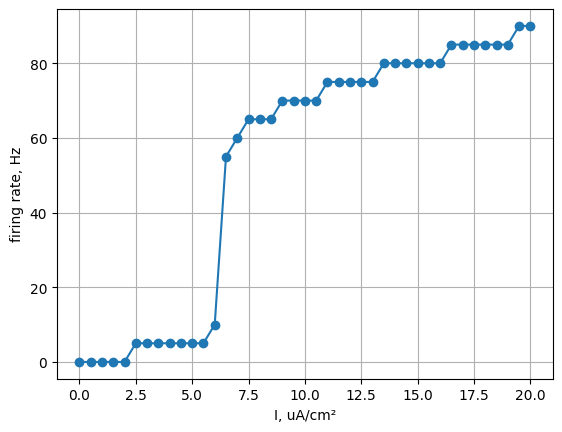

single onset spike from 2.5 uA/cm^2
sustained firing from 6.5 uA/cm^2 at 55 Hz


In [ ]:
currents = np.arange(0, 20.1, 0.5)
rates = []
for I_amp in currents:
    t, V, _, _ = hh(I_amp, T=250.0, t_on=20.0, t_off=220.0)
    rates.append(count_spikes(V) / 0.2)       # 200 ms window -> Hz

plt.plot(currents, rates, 'o-')
plt.xlabel('I, uA/cm²'); plt.ylabel('firing rate, Hz'); plt.grid(True)
plt.show()

single = next(i for i, r in enumerate(rates) if r > 0)
sustained = next(i for i, r in enumerate(rates) if r > 10)
print(f"single onset spike from {currents[single]} uA/cm^2")
print(f"sustained firing from {currents[sustained]} uA/cm^2 at {rates[sustained]:.0f} Hz")

## Summary

- The action potential, overshoot and after-hyperpolarisation all emerge from the
  equations; nothing about the spike shape is hard-coded.
- The spike is one-directional because Na⁺ activation is fast and self-reinforcing, Na⁺
  inactivation and K⁺ activation are slow: $g_{Na}$ peaks and collapses before $g_K$ peaks.
- Rheobase ≈ 2.3 µA/cm² has no closed form; it is where inward Na⁺ current first outruns the
  outward currents.
- Just above rheobase HH fires once and stops; sustained firing starts abruptly at ~55 Hz.
  HH is a type II neuron (discontinuous F–I onset), LIF is type I. The difference comes from
  the K⁺ current and Na⁺ inactivation, which LIF does not have.
- Euler integration needs $dt \ll \tau_m \approx 0.1$ ms — a numerical-stability constraint
  that LIF never imposed.